In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cmcrameri.cm as cmc
from src.algos.glsae import glsae
import json

rng = np.random.default_rng()
target = 1/3.0
length = 13

In [ ]:
for i in range(2, length):
    with open(f'./data/invariance/{2**(2*i+2)}.jsonl', 'w') as f:
        for _ in range(100):
            diff = [glsae(target, j, 2**(2*i+2)//j, rng, sigma = 3, sample_repeat=100, G=2**(i+2)//j) for j in 2**np.arange(np.max((1, i-7)), i)]
            y, x, z = zip(*diff)
            json.dump({"query": np.array(x).tolist(),"value": np.array(y).tolist(), "depth": np.array(z).tolist()}, f)
            f.write("\n")

In [4]:
plt.rcParams.update({'font.size': 12, 'font.family': "serif", 'text.usetex': True, 'text.latex.preamble': r'\usepackage{amsfonts}'})

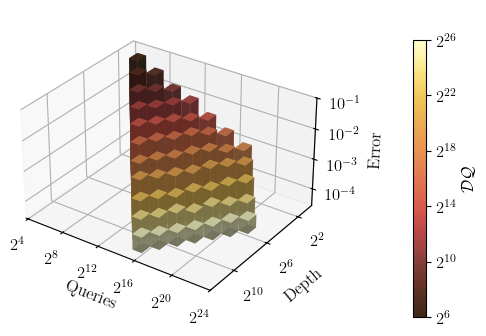

In [5]:
from matplotlib.colors import LinearSegmentedColormap
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((1.8, 1.5, 1))  
ax.view_init(azim=-55)

def truncate_colormap(cmap, minval=0.1, maxval=0.9, n=256):
    return LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )

# Original colormap
cmap = cmc.lajolla

# Truncated colormap (remove saturated ends)
cmap = truncate_colormap(cmap, 0.15, 1)
norm = plt.Normalize(vmin=2, vmax=12)

for i in range(2, 13):
    with open(f'./data/invariance/{2**(2*i+2)}.jsonl', 'r') as json_file:
        json_list = list(json_file)

    query = []
    depth = []
    value = []

    for json_str in json_list:
        res = json.loads(json_str)
        query.append(res["query"])
        depth.append(res["depth"])
        value.append(res["value"])

    query = np.max(query, axis=0)
    depth = np.max(depth, axis=0)
    error = np.mean(np.abs(np.stack(value, axis=0) - target), axis=0)

    color = cmap(norm(i))

    ax.bar3d(
        np.log2(query),
        np.log2(depth),
        np.zeros(len(query)),
        np.ones(len(query)),
        np.ones(len(query)),
        np.log10(error) + 4.5,
        color=color,
        alpha=0.8,
        linewidth=0,
        shade=True
    )

ax.set_xlabel("Queries")
ax.set_ylabel("Depth")
ax.set_zlabel("Error")

ax.set_xticks(
    range(4, 2 * length, 4),
    [rf"$2^{{{j}}}$" for j in range(4, 2 * length, 4)]
)
ax.set_yticks(
    range(2, length, 4),
    [rf"$2^{{{j}}}$" for j in range(2, length, 4)]
)
ax.set_zticks(
    np.arange(0.5, 4.5),
    [rf"$10^{{{int(j-4.5)}}}$" for j in np.arange(0.5, 4.5)]
)

ax.invert_yaxis()

# Optional: replace legend with colorbar (recommended)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.12, shrink=0.9,
    anchor=(0.0, 0.0))

# Place ticks at integer i values
ticks = np.arange(2, 13, 2)
cbar.set_ticks(ticks)

# Relabel ticks as DN = 2^{2i+2}
cbar.set_ticklabels(
    [rf"$2^{{{2*i+2}}}$" for i in ticks]
)

cbar.set_label(r"$\mathcal{DQ}$")

plt.savefig("./output/invariance.pdf", bbox_inches='tight')
plt.show()